# 06 - Statistical Deep Dive: Sales Dataset

## 📌 Objective
This notebook performs a rigorous statistical validation of the Sales dataset. We use hypothesis testing and multivariate diagnostics to justify our feature engineering and ensure the model training data is mathematically sound.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import IsolationForest

%matplotlib inline
sns.set_theme(style="whitegrid")

# Load Model-Ready Sales Data
df = pd.read_parquet("../data/model/model_sales.parquet")
print(f"🔹 Auditing {len(df):,} Sales Records")

🔹 Auditing 19,147 Sales Records


## 1. Normality & Transformation Audit
Most parametric models assume normal distribution. We test the raw target vs the log-transformed target using the **Shapiro-Wilk** test (on a sample due to size limits) and **Q-Q Plots**.

Shapiro-Wilk p-value (Raw): 0.0000
Shapiro-Wilk p-value (Log): 0.0000


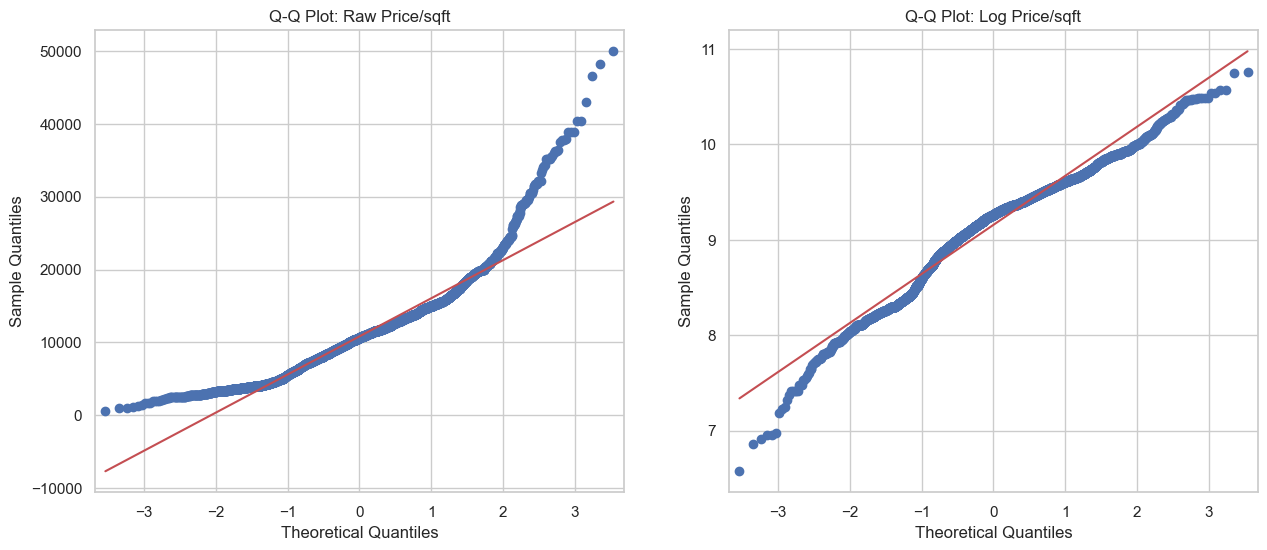

In [2]:
target = df['price_per_sqft']
log_target = np.log1p(target)

sample_target = target.sample(min(5000, len(target)))
sample_log = log_target.sample(min(5000, len(log_target)))

_, p_raw = stats.shapiro(sample_target)
_, p_log = stats.shapiro(sample_log)

print(f"Shapiro-Wilk p-value (Raw): {p_raw:.4f}")
print(f"Shapiro-Wilk p-value (Log): {p_log:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sm.qqplot(sample_target, line='s', ax=ax[0])
ax[0].set_title("Q-Q Plot: Raw Price/sqft")
sm.qqplot(sample_log, line='s', ax=ax[1])
ax[1].set_title("Q-Q Plot: Log Price/sqft")
plt.show()

## 2. Categorical Variance (ANOVA)
Is the price variance across different cities statistically significant? We use One-Way ANOVA to test the hypothesis that City has a significant impact on Price.

In [3]:
# ANOVA: price_per_sqft ~ city
model = ols('price_per_sqft ~ C(city)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Results for City Effect:")
print(anova_table)

# If p < 0.05, City is a statistically significant feature.

ANOVA Results for City Effect:
                sum_sq       df           F  PR(>F)
C(city)   1.338849e+11      4.0  1742.63582     0.0
Residual  3.676650e+11  19142.0         NaN     NaN


## 3. Multivariate Outlier Detection (Isolation Forest)
Instead of univariate clipping, we use an Isolation Forest to identify properties that are anomalous across multiple dimensions (Area, Bedrooms, Bathrooms, Price).

Detected 192 multivariate anomalies (1% contamination)


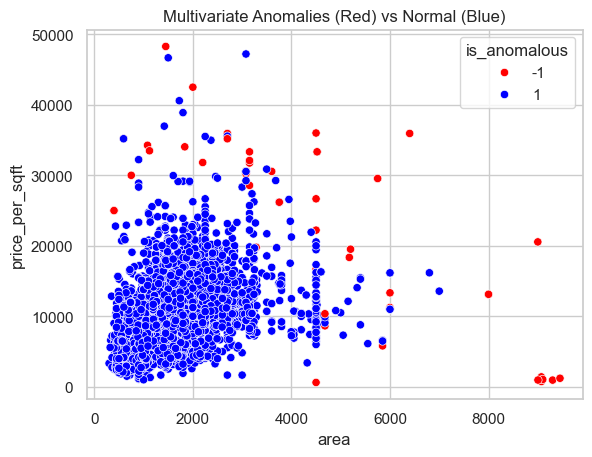

In [4]:
iso_cols = ['area', 'bedrooms', 'bathrooms', 'price_per_sqft']
iso_df = df[iso_cols].dropna()
iso = IsolationForest(contamination=0.01, random_state=42)
df['is_anomalous'] = iso.fit_predict(iso_df)

anomalies = df[df['is_anomalous'] == -1]
print(f"Detected {len(anomalies)} multivariate anomalies (1% contamination)")

sns.scatterplot(x='area', y='price_per_sqft', hue='is_anomalous', data=df.sample(5000), palette={1:'blue', -1:'red'})
plt.title("Multivariate Anomalies (Red) vs Normal (Blue)")
plt.show()

## 4. Spatial Clustering Significance
We test if prices are geographically clustered. If they are, it justifies our H3-based neighborhood median feature.

In [5]:
corr = df[['price_per_sqft', 'h3_median_price']].dropna().corr().iloc[0, 1]
print(f"Correlation between Property Price and Neighborhood Median: {corr:.4f}")

# High correlation (>0.7) indicates strong spatial dependency.

Correlation between Property Price and Neighborhood Median: 0.6266
